# Exploratory Data Analysis

Visualize trends, distributions, and relationships in the dataset.

# Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore the cleaned Samsung smartphone dataset, understand feature distributions, identify relationships between variables, and derive business insights that will support feature engineering and model development.

Input:
- data/processed/cleaned_dataset.csv

Output:
- Visualizations
- Statistical summaries
- Business insights

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
df = pd.read_csv("../data/processed/cleaned_dataset.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
print("Shape :", df.shape)

print("\nColumns:\n")
print(df.columns)

print("\nData Types:\n")
print(df.dtypes)

Shape : (749, 21)

Columns:

Index(['Name', 'Dimensions', 'SoC', 'CPU', 'GPU', 'RAM', 'Storage', 'Display',
       'Battery', 'OS', 'Camera', 'Launch_Year', 'Series', 'Main_Camera_MP',
       'UltraWide_MP', 'Telephoto_MP', 'Front_Camera_MP', 'OIS', 'AI_Features',
       'Waterproof', 'Target_Segment'],
      dtype='str')

Data Types:

Name                   str
Dimensions             str
SoC                    str
CPU                    str
GPU                    str
RAM                    str
Storage                str
Display                str
Battery                str
OS                     str
Camera                 str
Launch_Year        float64
Series                 str
Main_Camera_MP       int64
UltraWide_MP       float64
Telephoto_MP       float64
Front_Camera_MP    float64
OIS                    str
AI_Features            str
Waterproof             str
Target_Segment         str
dtype: object


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Name,749,749,Ativ Odyssey,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dimensions,720,472,75.9 x 164.2 x 9.1 mm,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SoC,749,176,Qualcomm Snapdragon 410 (MSM8916),32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CPU,749,123,"4x 1.2 GHz ARM Cortex-A53,",40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GPU,720,123,"Qualcomm Adreno 306, 400 MHz",32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RAM,749,124,"1.5 GB, 533 MHz",43,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Storage,749,41,16 GB,124,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Display,720,228,"5 in, Super AMOLED, 720 x 1280 pixels, 24 bit",19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Battery,749,117,"2600 mAh, Li-Ion",59,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OS,749,60,Android 10,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
Launch_Year,720,96.128171
Front_Camera_MP,720,96.128171
Camera,29,3.871829
GPU,29,3.871829
Dimensions,29,3.871829
Display,29,3.871829
CPU,0,0.000000
Name,0,0.000000
SoC,0,0.000000
Battery,0,0.000000


In [6]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


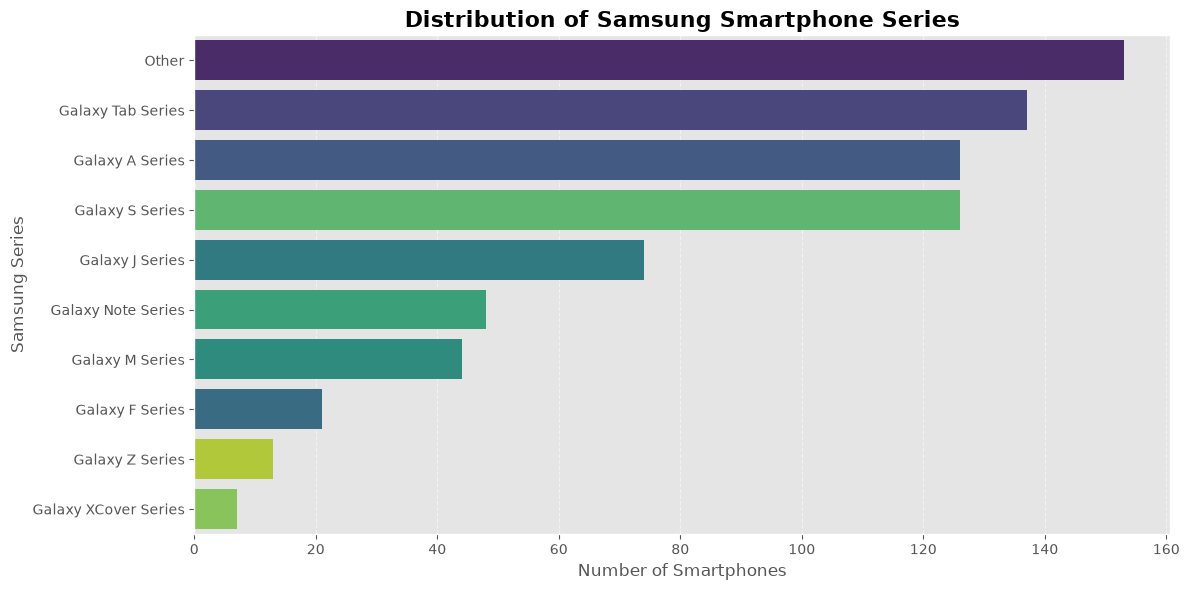

In [11]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="Series",
    order=df["Series"].value_counts().index,
    hue="Series",          # Avoids the seaborn palette warning
    palette="viridis",
    legend=False
)

plt.title("Distribution of Samsung Smartphone Series", fontsize=16, fontweight="bold")
plt.xlabel("Number of Smartphones")
plt.ylabel("Samsung Series")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

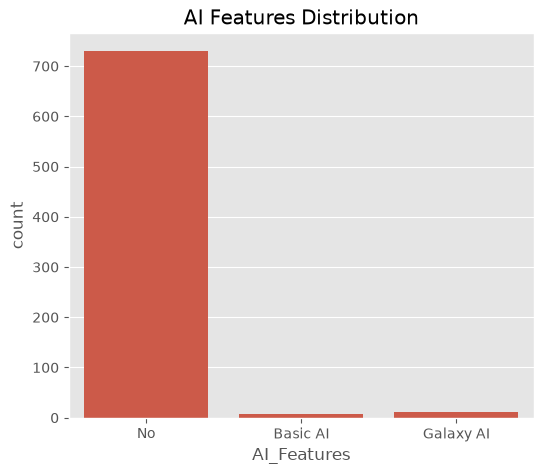

In [12]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="AI_Features"
)

plt.title("AI Features Distribution")
plt.show()

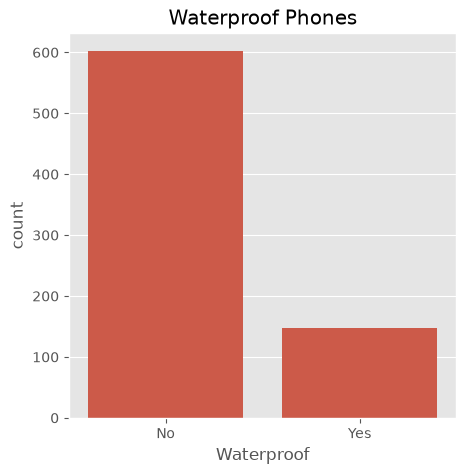

In [13]:
plt.figure(figsize=(5,5))

sns.countplot(
    data=df,
    x="Waterproof"
)

plt.title("Waterproof Phones")
plt.show()

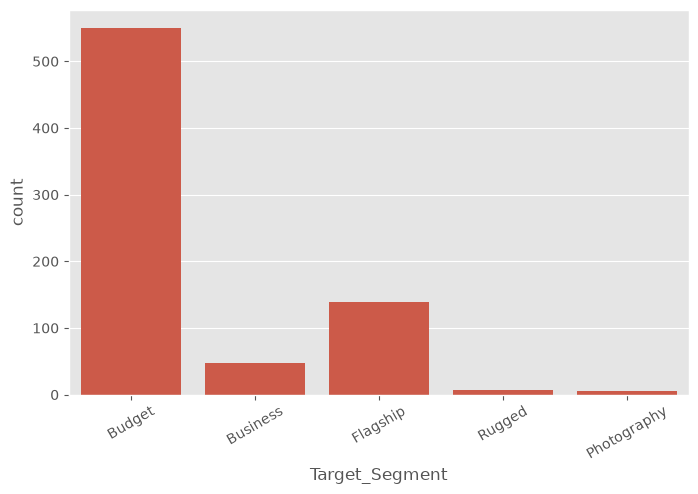

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Target_Segment"
)

plt.xticks(rotation=30)

plt.show()

In [17]:
import re

def extract_ram(ram):
    if pd.isna(ram):
        return None

    ram = str(ram)

    match = re.search(r'(\d+(?:\.\d+)?)\s*GB', ram, re.IGNORECASE)

    if match:
        return float(match.group(1))

    match = re.search(r'(\d+)\s*MB', ram, re.IGNORECASE)

    if match:
        return round(float(match.group(1)) / 1024, 2)

    return None

df["RAM_GB"] = df["RAM"].apply(extract_ram)

In [18]:
df[["RAM", "RAM_GB"]].head(15)

,RAM,RAM_GB
0,"1 GB, 400 MHz",1.00
1,"768 MB, 333 MHz",0.75
2,"1.5 GB, 400 MHz",1.50
3,"2 GB, 800 MHz",2.00
4,1 GB,1.00
5,512 MB,0.50
6,384 MB,0.38
7,"512 MB, 200 MHz",0.50
8,"1 GB, 500 MHz",1.00
9,768 MB,0.75


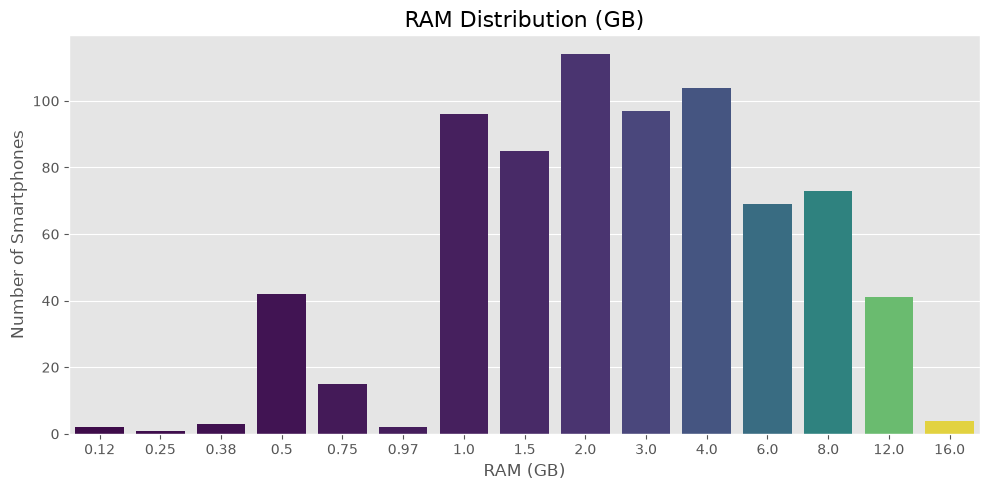

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="RAM_GB",
    order=sorted(df["RAM_GB"].dropna().unique()),
    hue="RAM_GB",
    palette="viridis",
    legend=False
)

plt.title("RAM Distribution (GB)", fontsize=16)
plt.xlabel("RAM (GB)")
plt.ylabel("Number of Smartphones")

plt.tight_layout()

plt.show()

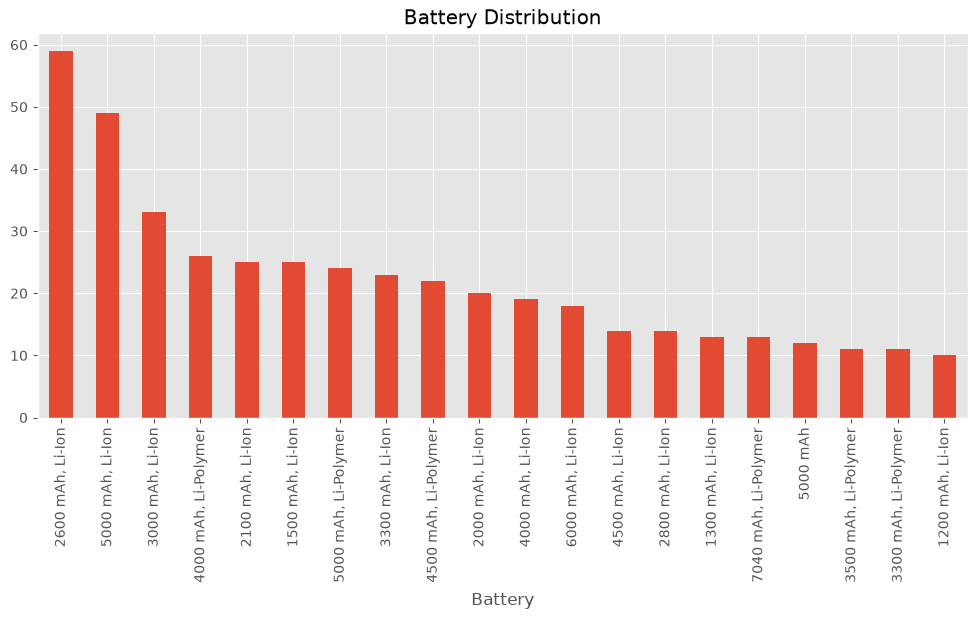

In [20]:
df["Battery"].value_counts().head(20).plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Battery Distribution")
plt.show()

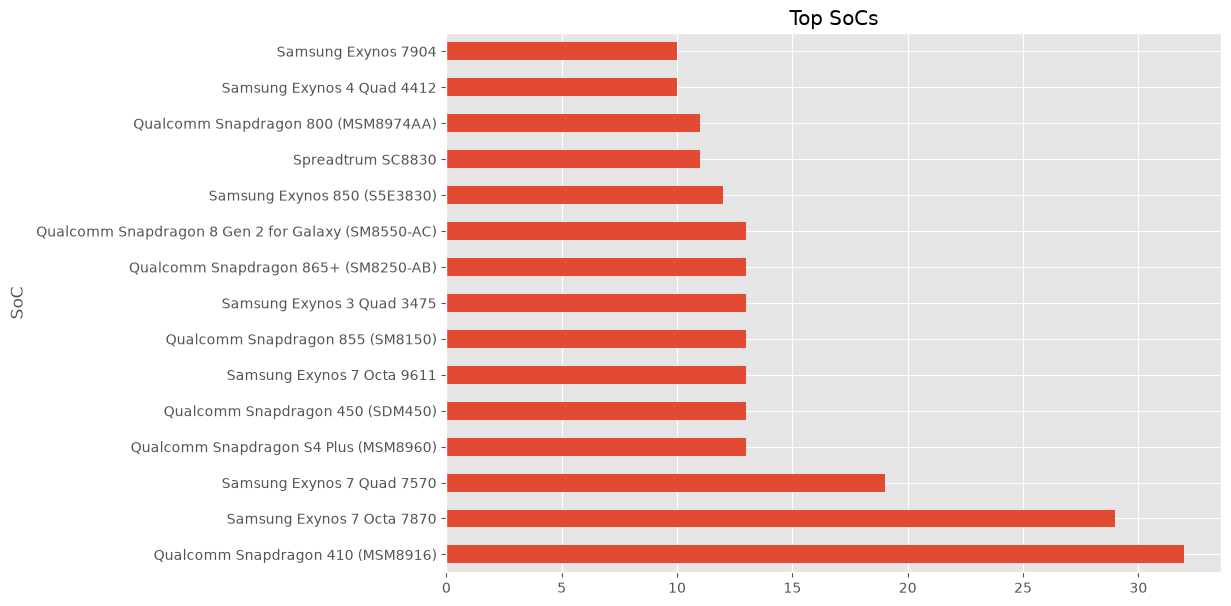

In [21]:
df["SoC"].value_counts().head(15).plot(
    kind="barh",
    figsize=(10,7)
)

plt.title("Top SoCs")
plt.show()

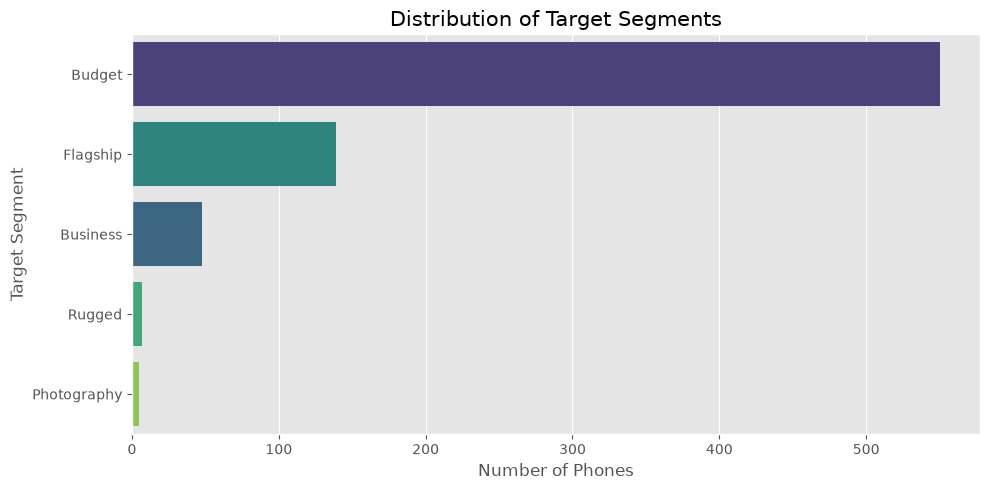

In [22]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="Target_Segment",
    order=df["Target_Segment"].value_counts().index,
    hue="Target_Segment",
    palette="viridis",
    legend=False
)

plt.title("Distribution of Target Segments", fontsize=15)
plt.xlabel("Number of Phones")
plt.ylabel("Target Segment")

plt.tight_layout()
plt.show()

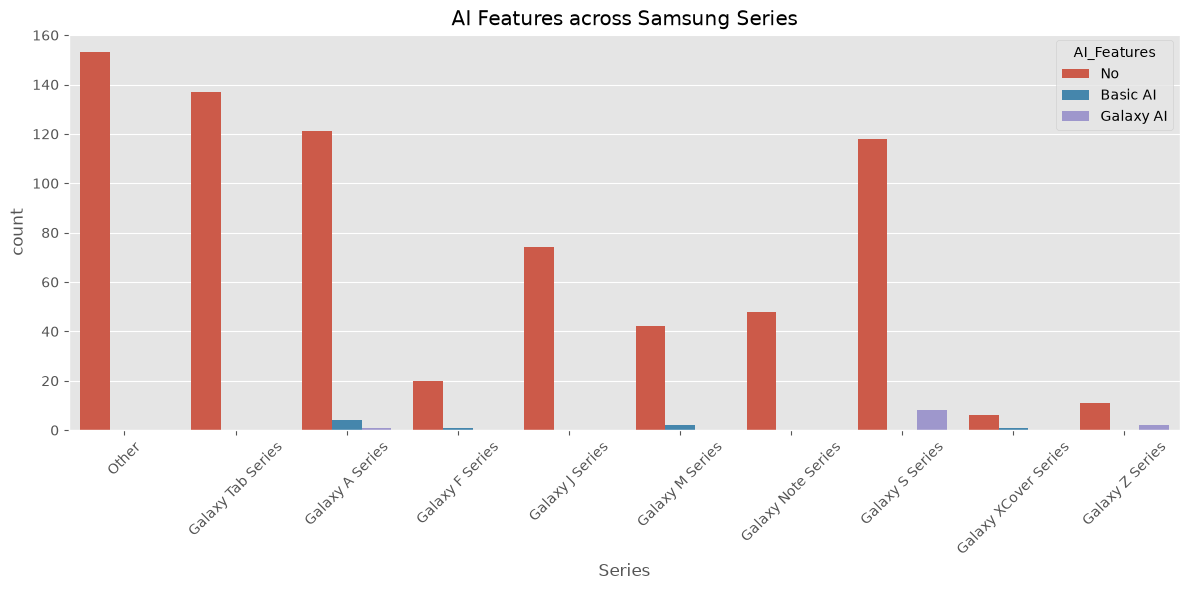

In [23]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="Series",
    hue="AI_Features"
)

plt.xticks(rotation=45)

plt.title("AI Features across Samsung Series")

plt.tight_layout()
plt.show()

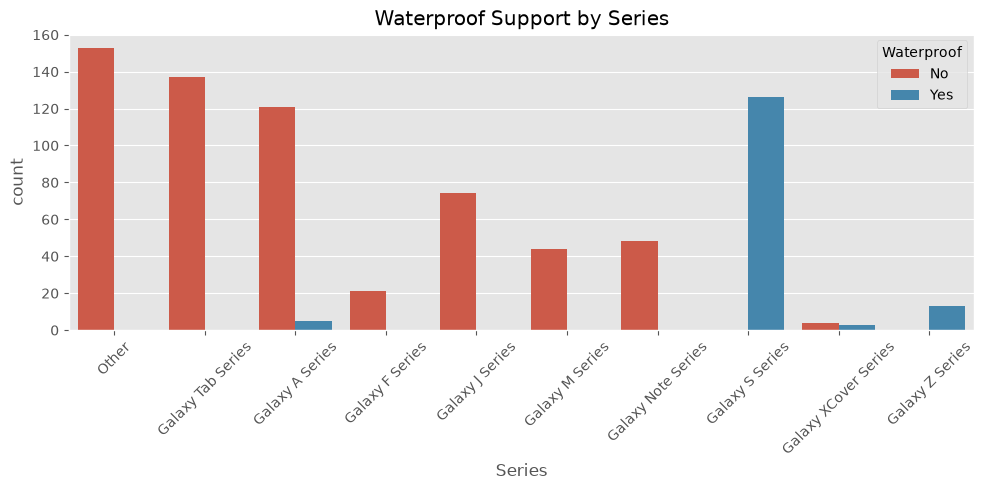

In [24]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Series",
    hue="Waterproof"
)

plt.xticks(rotation=45)

plt.title("Waterproof Support by Series")

plt.tight_layout()
plt.show()

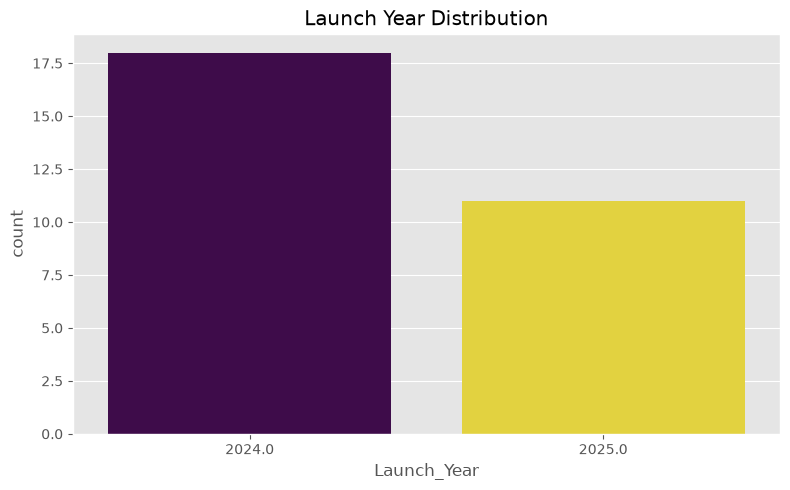

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Launch_Year",
    hue="Launch_Year",
    palette="viridis",
    legend=False
)

plt.title("Launch Year Distribution")

plt.tight_layout()

plt.show()

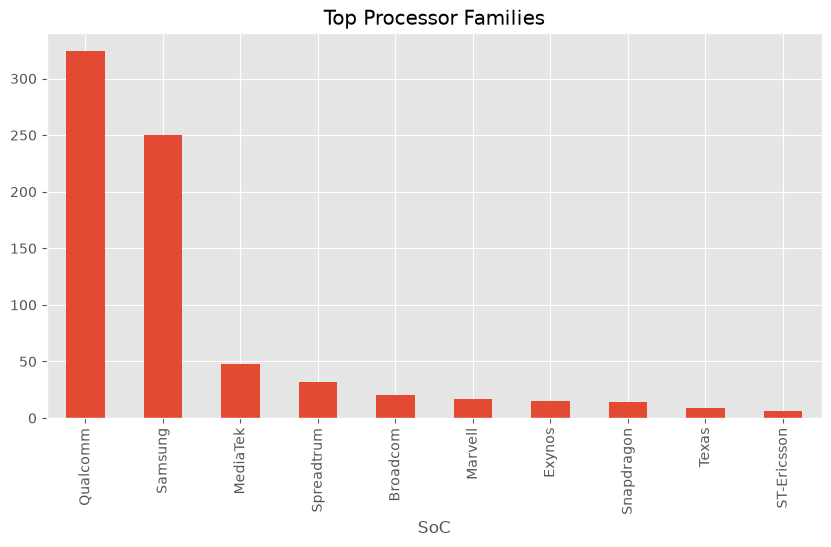

In [26]:
df["SoC"].str.split().str[0].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Processor Families")

plt.show()

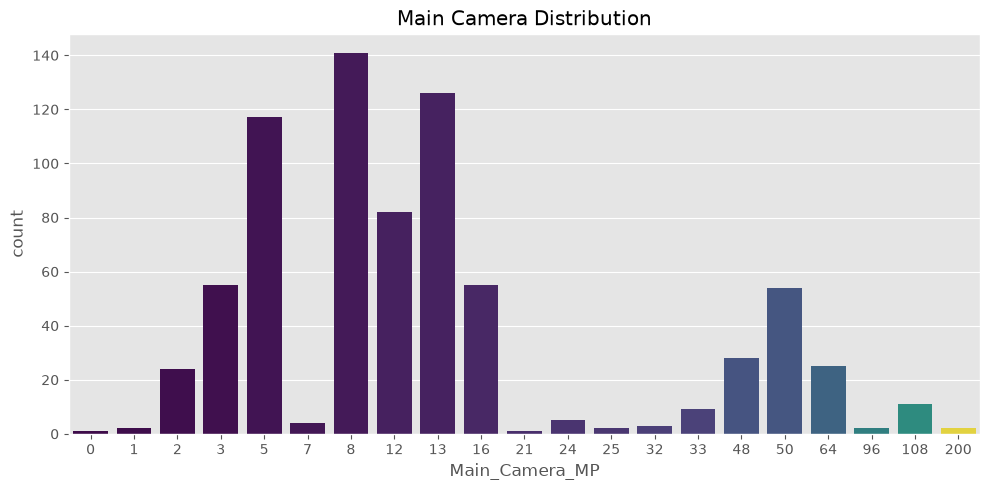

In [27]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Main_Camera_MP",
    order=sorted(df["Main_Camera_MP"].dropna().unique()),
    hue="Main_Camera_MP",
    palette="viridis",
    legend=False
)

plt.title("Main Camera Distribution")

plt.tight_layout()

plt.show()

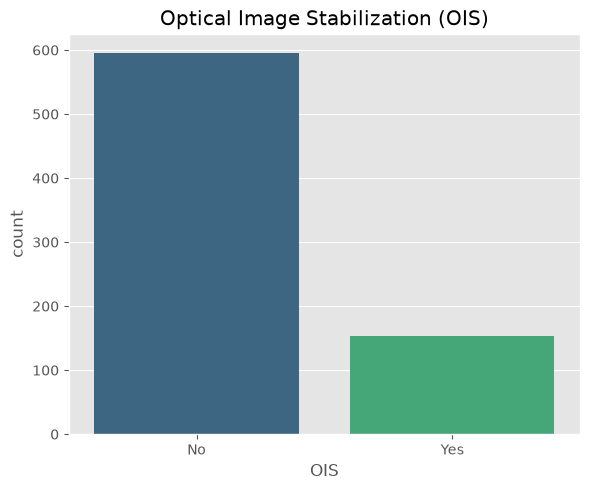

In [28]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="OIS",
    hue="OIS",
    palette="viridis",
    legend=False
)

plt.title("Optical Image Stabilization (OIS)")

plt.tight_layout()

plt.show()

## Key Insights

1. Samsung's smartphone portfolio is dominated by legacy devices, while the A Series is the largest among current smartphone lineups.

2. Galaxy AI is mainly available in premium and recently launched smartphones, whereas budget models generally lack AI capabilities.

3. Waterproof certification is concentrated in mid-range and flagship devices.

4. Samsung offers a wide range of processors, with Snapdragon, Exynos, and MediaTek being the dominant families.

5. Most smartphones feature 50 MP or 108 MP primary cameras, while flagship devices provide additional ultrawide and telephoto lenses.

6. The dataset covers a broad spectrum of devices across different price ranges and user segments, making it suitable for building a recommendation system.